# EJEMPLO Adult Data

https://archive.ics.uci.edu/dataset/2/adult

https://www.kaggle.com/datasets/wenruliu/adult-income-dataset


In [1]:
# Importamos las librerias necesarias
import tensorflow.keras as keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# DATOS

**Radiografía de los Datos (Features)**

El dataset original cuenta con unas 32.561 filas de entrenamiento y 14 variables predictoras, que mezclan datos continuos y categóricos. Estas variables se pueden agrupar en tres grandes dimensiones:

**Variables Demográficas**: Edad (age), sexo (sex), raza (race), estado civil (marital-status), país de origen (native-country) y el rol dentro de la familia (relationship).

**Variables Educativas y Laborales**: Nivel educativo más alto alcanzado (education), los años de estudio cuantificados (education-num), el tipo de empleador (workclass - como sector privado, gobierno o autónomo), el tipo de profesión (occupation) y las horas trabajadas por semana (hours-per-week).

**Variables Financieras y de Muestreo**: Ganancias de capital (capital-gain), pérdidas de capital (capital-loss) y una variable peculiar llamada fnlwgt (final weight), que es un control demográfico que indica a cuántas personas de la población estadounidense representa esa fila específica.

In [2]:
COLUMNS = ["age", "workclass", "fnlwgt", "education", "education_num",
           "marital_status", "occupation", "relationship", "race", "gender",
           "capital_gain", "capital_loss", "hours_per_week", "native_country",
           "income_bracket"]

train_csv = tf.keras.utils.get_file('adult.data',
  'https://download.mlcc.google.com/mledu-datasets/adult_census_train.csv')
test_csv = tf.keras.utils.get_file('adult.data',
  'https://download.mlcc.google.com/mledu-datasets/adult_census_test.csv')

train_df = pd.read_csv(train_csv, names=COLUMNS, sep=r'\s*,\s*',
                       engine='python', na_values="?")
test_df = pd.read_csv(test_csv, names=COLUMNS, sep=r'\s*,\s*', skiprows=[0],
                      engine='python', na_values="?")

In [3]:
train_df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,gender,capital_gain,capital_loss,hours_per_week,native_country,income_bracket
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


# Preprocesamos los datos para simplificar

In [4]:
train_df_num = train_df

In [5]:
# remplazamos categóricas por numéricas
train_df_num['income_bracket'].replace(['<=50K', '>50K'],[0, 1], inplace=True)
train_df_num['race'].replace(["White", "Asian-Pac-Islander", "Amer-Indian-Eskimo", "Other", "Black"],[0, 1, 2, 3, 4], inplace=True)
train_df_num['gender'].replace(['Male', 'Female'],[0, 1], inplace=True)

/tmp/ipykernel_1274/3163574001.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df_num['income_bracket'].replace(['<=50K', '>50K'],[0, 1], inplace=True)
/tmp/ipykernel_1274/3163574001.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df_num['income_bracket'].replace(['<=50K', '>50K'

In [6]:
# Quitamos
train_df_num = train_df_num.drop(['marital_status','occupation','relationship','education','workclass','native_country'], axis='columns')

In [7]:
train_df_num

,age,fnlwgt,education_num,race,gender,capital_gain,capital_loss,hours_per_week,income_bracket
0,39,77516,13,0,0,2174,0,40,0
1,50,83311,13,0,0,0,0,13,0
2,38,215646,9,0,0,0,0,40,0
3,53,234721,7,4,0,0,0,40,0
4,28,338409,13,4,1,0,0,40,0
...,...,...,...,...,...,...,...,...,...
32556,27,257302,12,0,1,0,0,38,0
32557,40,154374,9,0,0,0,0,40,1
32558,58,151910,9,0,1,0,0,40,0
32559,22,201490,9,0,0,0,0,20,0


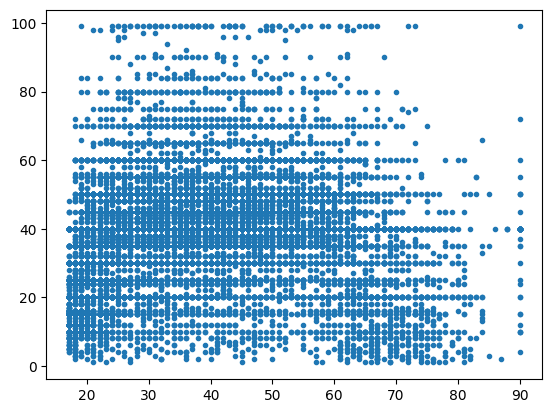

In [8]:
plt.plot(train_df_num['age'],train_df_num['hours_per_week'],'.')

In [9]:
np.corrcoef(train_df_num['gender'],train_df_num['income_bracket'])[0,1]

np.float64(-0.21598015058403627)

In [10]:
np.corrcoef(train_df_num['race'],train_df_num['income_bracket'])[0,1]

np.float64(-0.09683865434347871)

In [11]:
DATA = train_df_num.values
DATA = DATA.astype('float32')

In [12]:
# estandarizamos las variables no binarias
from scipy import stats
DATA[:,0] =  (DATA[:,0]-np.mean(DATA[:,0]))/np.std(DATA[:,0])
DATA[:,1] =  (DATA[:,1]-np.mean(DATA[:,1]))/np.std(DATA[:,1])
DATA[:,5] =  (DATA[:,5]-np.mean(DATA[:,5]))/np.std(DATA[:,5])
DATA[:,6] =  (DATA[:,6]-np.mean(DATA[:,6]))/np.std(DATA[:,6])
DATA[:,7] =  (DATA[:,7]-np.mean(DATA[:,7]))/np.std(DATA[:,7])

In [13]:
np.corrcoef(DATA.T)

array([[ 1.00000000e+00, -7.66458678e-02,  3.65271883e-02,
        -2.98690064e-02, -8.88317306e-02,  7.76744985e-02,
         5.77745406e-02,  6.87557045e-02,  2.34037102e-01],
       [-7.66458678e-02,  1.00000000e+00, -4.31946329e-02,
         9.84060945e-02, -2.68580448e-02,  4.31885725e-04,
        -1.02517116e-02, -1.87684905e-02, -9.46255711e-03],
       [ 3.65271883e-02, -4.31946329e-02,  1.00000000e+00,
        -7.87992357e-02, -1.22800543e-02,  1.22630115e-01,
         7.99229562e-02,  1.48122733e-01,  3.35153953e-01],
       [-2.98690064e-02,  9.84060945e-02, -7.87992357e-02,
         1.00000000e+00,  1.17362676e-01, -1.99904866e-02,
        -2.39257763e-02, -5.44432482e-02, -9.68386543e-02],
       [-8.88317306e-02, -2.68580448e-02, -1.22800543e-02,
         1.17362676e-01,  1.00000000e+00, -4.84796468e-02,
        -4.55673544e-02, -2.29309149e-01, -2.15980151e-01],
       [ 7.76744985e-02,  4.31885725e-04,  1.22630115e-01,
        -1.99904866e-02, -4.84796468e-02,  1.000000

In [14]:
X = DATA[:,0:-1]
Y = DATA[:,-1:]

In [15]:
print(X.shape)
print(Y.shape)

(32561, 8)
(32561, 1)


## POR GENERO

In [30]:
N = 10000

x_train = X
y_train = Y[:,0]

# Variable sensitiva
# 3 race
# 4 gender
s = x_train[:,4]

In [19]:
A = np.zeros((2,2))
A[0,0] = np.sum(np.argwhere(y_train[np.argwhere(s==0)]==0))
A[0,1] = np.sum(np.argwhere(y_train[np.argwhere(s==0)]==1))
A[1,0] = np.sum(np.argwhere(y_train[np.argwhere(s==1)]==0))
A[1,1] = np.sum(np.argwhere(y_train[np.argwhere(s==1)]==1))
A
A_norm = A
A_norm[0,:] = A[0,:]/sum(A[0,:])
A_norm[1,:] = A[1,:]/sum(A[1,:])

Text(0.5, 1.0, 'coor: -0.21598015058403627')

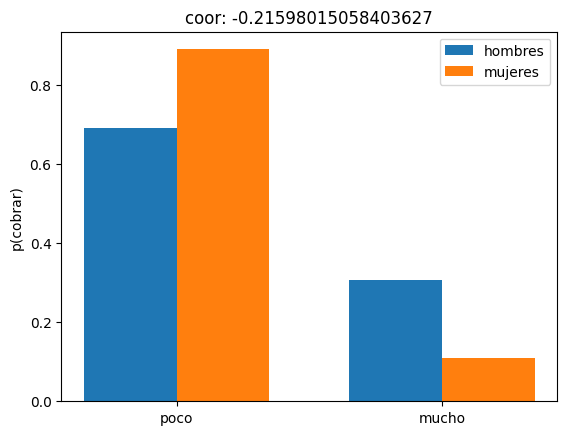

In [20]:
fig, ax = plt.subplots()

width = 0.35
ax.bar([- width/2,1- width/2] ,A_norm[0,:],width,label='hombres')
ax.bar([0+ width/2,1+ width/2] ,A_norm[1,:],width,label='mujeres')
ax.legend()
ax.set_ylabel('p(cobrar)')
#plt.xlabel('cobran')
ax.set_xticks([0,1])
ax.set_xticklabels(['poco','mucho'])
ax.set_title('coor: ' + str(np.corrcoef(s,y_train)[0,1]))

## POR RAZA

In [31]:

# Variable sensitiva
# 2 race
# 3 gender
s = x_train[:,3]

/tmp/ipykernel_1274/1065632488.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Dark2', num_sensitive_categories)


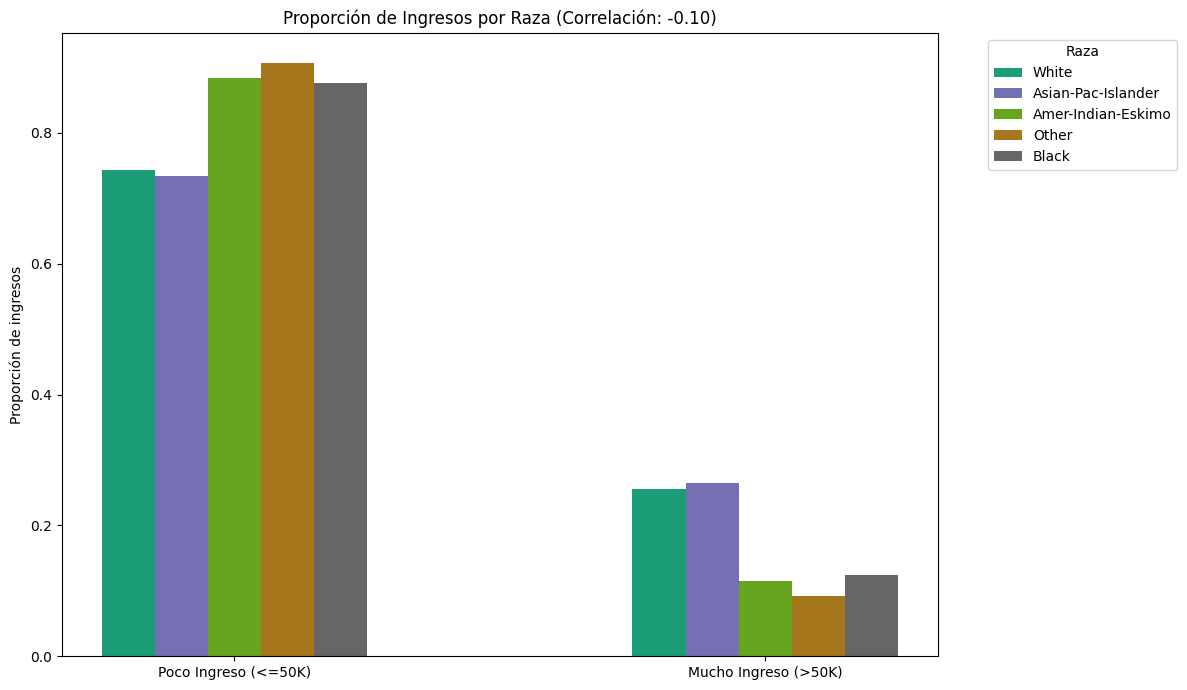

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming s and y_train are defined from previous cells.
# s = x_train[:,2] (race)
# y_train = Y (income_bracket)

unique_s_values = np.unique(s)
num_sensitive_categories = unique_s_values.shape[0]

A = np.zeros((num_sensitive_categories, 2))
for i, s_val in enumerate(unique_s_values):
    y_for_s_val = y_train[s == s_val]
    A[i, 0] = np.sum(y_for_s_val == 0) # Count of <=50K
    A[i, 1] = np.sum(y_for_s_val == 1) # Count of >50K

A_norm = np.copy(A)
for i in range(num_sensitive_categories):
    total_for_s_val = np.sum(A[i, :])
    if total_for_s_val > 0:
        A_norm[i, :] = A[i, :] / total_for_s_val
    else:
        A_norm[i, :] = 0

race_labels = ["White", "Asian-Pac-Islander", "Amer-Indian-Eskimo", "Other", "Black"]
income_bracket_labels = ['Poco Ingreso (<=50K)', 'Mucho Ingreso (>50K)']

fig, ax = plt.subplots(figsize=(12, 7))

bar_width = 0.1
# Calculate the total width occupied by all bars for one income group
total_group_width = bar_width * num_sensitive_categories

# Define the base positions for the two income brackets on the x-axis
x_income_0_base = 0
x_income_1_base = 1

# Get a color map for distinct categories
colors = plt.cm.get_cmap('Dark2', num_sensitive_categories)

# Plot bars for each race
for i, s_val in enumerate(unique_s_values):
    # Calculate the x-position for each bar within its income group
    # This centers the group of bars around the base x-position
    x_pos_0 = x_income_0_base - (total_group_width / 2) + (i * bar_width) + bar_width / 2
    x_pos_1 = x_income_1_base - (total_group_width / 2) + (i * bar_width) + bar_width / 2

    ax.bar(x_pos_0, A_norm[i, 0], bar_width, color=colors(i), label=race_labels[int(s_val)])
    ax.bar(x_pos_1, A_norm[i, 1], bar_width, color=colors(i)) # No label here to avoid duplicate legend entries

ax.set_ylabel('Proporción de ingresos')
ax.set_xticks([x_income_0_base, x_income_1_base])
ax.set_xticklabels(income_bracket_labels)
ax.set_title(f'Proporción de Ingresos por Raza (Correlación: {np.corrcoef(s, y_train)[0,1]:.2f})')
ax.legend(title='Raza', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()